In [ ]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

In [ ]:
from __future__ import annotations

import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np


# ----------------------------
# Basic utilities
# ----------------------------

def normal_pdf(x: np.ndarray) -> np.ndarray:
    return np.exp(-0.5 * x * x) / math.sqrt(2 * math.pi)

def normal_cdf(x: np.ndarray) -> np.ndarray:
    return 0.5 * (1.0 + np.vectorize(math.erf)(x / math.sqrt(2.0)))

def running_mean(samples: np.ndarray) -> np.ndarray:
    csum = np.cumsum(samples, axis=1)
    n = np.arange(1, samples.shape[1] + 1)
    return csum / n

In [ ]:
import matplotlib.pyplot as plt

# Explicitly disable LaTeX rendering
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'

# 1) Strong Law of Large Numbers (SLLN)

### Explanation

The Strong Law of Large Numbers (SLLN) states that if $X_1, X_2, \dots$ is a sequence of independent and identically distributed (i.i.d.) random variables with finite expected value $E[X_1] = \mu$, then the sample average $\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$ converges almost surely to $\mu$ as $n \to \infty$. This can be formally written as:

$$ \mathbb{P}\left(\lim_{n\to\infty} \bar{X}_n = \mu\right) = 1 $$

This means that for almost every realization of the sequence, the sample average will eventually stay arbitrarily close to the true mean $\mu$. In simpler terms, if you keep taking more samples, your average will almost certainly get closer and closer to the true average of the population.

### Simulation Details

We demonstrate the SLLN using Bernoulli(0.3) data. We generate multiple paths of random variables and compute their running means. We visualize two aspects:

1.  **Individual Sample Paths**: Several sample paths of $\bar{X}_n$ are plotted against $n$. We expect these paths to converge to the true mean $\mu = 0.3$.
2.  **Finite-Horizon Proxy for Eventual Convergence**: We approximate $\mathbb{P}(\max_{k \ge n} |\bar{X}_k - \mu| > \varepsilon)$ over a finite horizon. This is a simulation-friendly proxy for the strong statement of convergence. As $n$ increases, this probability should tend towards zero, indicating that the paths eventually stay within an $\varepsilon$-band around $\mu$. Here, $\varepsilon$ is a small positive value (e.g., $0.12$).

The running mean is calculated as:

$$ \bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i $$

where $X_i \sim \text{Bernoulli}(p)$ and $\mu = p = 0.3$.

In [ ]:
from dataclasses import dataclass # This import might not be strictly needed if SLLNConfig is removed, but keeping it doesn't harm.

def slln_demo(n_max: int = 5000, epsilon: float = 0.12) -> None:
    """
    Demonstrates pathwise convergence using Bernoulli(0.3) data.

    Figure 1:
        Several sample paths of X̄_n approaching μ.
    Figure 2:
        Approximate P(max_{k >= n} |X̄_k - μ| > ε) over a finite horizon,
        which is a simulation-friendly proxy for the strong statement.
    """
    # Fixed configuration values for now. These can be made interactive if needed.
    display_paths: int = 12
    monitor_paths: int = 3000
    seed: int = 7

    rng = np.random.default_rng(seed)
    p = 0.3
    mu = p

    # Paths for classroom display
    x = rng.binomial(1, p, size=(display_paths, n_max))
    means = running_mean(x)

    n = np.arange(1, n_max + 1)

    plt.figure(figsize=(10, 6))
    for i in range(display_paths):
        plt.plot(n, means[i], alpha=0.8)
    plt.axhline(mu, linestyle="--", label=r"true mean $\mu$")
    plt.axhline(mu + epsilon, linestyle=":", label=r"$\mu \pm \varepsilon$")
    plt.axhline(mu - epsilon, linestyle=":")
    plt.xlabel("n")
    plt.ylabel(r"running average $\bar X_n$")
    plt.title("SLLN: sample paths of the running average")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Larger batch for a finite-horizon proxy to 'eventually stay inside'
    y = rng.binomial(1, p, size=(monitor_paths, n_max))
    means_big = running_mean(y)
    deviation = np.abs(means_big - mu)

    # tail_event[n] = event that there exists k >= n with |X̄_k - μ| > ε
    reversed_max = np.maximum.accumulate(deviation[:, ::-1], axis=1)[:, ::-1]
    tail_event_prob = (reversed_max > epsilon).mean(axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(n, tail_event_prob)
    plt.xlabel("n")
    plt.ylabel(
        r"fraction of paths with $\max_{k \geq n} |\bar X_k - \mu| > \varepsilon$"
    )
    plt.title("SLLN: finite-horizon proxy for eventual convergence")
    plt.tight_layout()
    plt.show()


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

print("Interactive SLLN Simulation:")

interact(slln_demo,
         n_max=widgets.IntSlider(min=100, max=10000, step=100, value=5000, description='n_max'),
         epsilon=widgets.FloatSlider(min=0.01, max=0.5, step=0.01, value=0.12, description='Epsilon')
        );

Interactive SLLN Simulation:


interactive(children=(IntSlider(value=5000, description='n_max', max=10000, min=100, step=100), FloatSlider(va…

# 2) Weak Law of Large Numbers (WLLN)

### Explanation

The Weak Law of Large Numbers (WLLN) states that the sample average $\bar{X}_n$ converges in probability to the expected value $\mu$. Formally, for any positive number $\varepsilon > 0$:

$$ \lim_{n\to\infty} \mathbb{P}\left(|\bar{X}_n - \mu| > \varepsilon\right) = 0 $$

This means that as the number of samples $n$ increases, the probability that the sample average $\bar{X}_n$ is far from the true mean $\mu$ becomes very small. It's a weaker statement than SLLN because it doesn't guarantee that the specific sequence of averages will converge, only that the *probability* of deviation decreases.

### Simulation Details

We demonstrate convergence in probability for Bernoulli(0.3) data. We calculate the empirical probability $\mathbb{P}(|\bar{X}_n - \mu| > \varepsilon)$ and compare it with the Chebyshev and Hoeffding bounds.

-   **Empirical Probability**: Calculated as the fraction of trials where the absolute difference between the sample mean and true mean exceeds $\varepsilon$.

    $$ \mathbb{P} \left(|\bar{X}_n - \mu| > \varepsilon\right) \approx \frac{1}{\mathrm{trials}} \sum_{j=1}^{\mathrm{trials}} \mathbf{1}_{|\bar{X}_{n,j} - \mu| > \varepsilon}. $$

-   **Chebyshev's Inequality**: Provides an upper bound on the probability of deviation:

    $$ \mathbb{P}(|\bar{X}_n - \mu| > \varepsilon) \le \frac{\text{Var}(\bar{X}_n)}{\varepsilon^2} = \frac{\sigma^2}{n\varepsilon^2} $$

    For Bernoulli($p$) variables, $\sigma^2 = p(1-p)$. So, for the sample mean, $\text{Var}(\bar{X}_n) = \frac{p(1-p)}{n}$.

-   **Hoeffding's Inequality**: Provides a tighter bound for bounded random variables. For i.i.d. random variables $X_i \in [a, b]$ with mean $\mu$:

    $$ \mathbb{P}(|\bar{X}_n - \mu| > \varepsilon) \le 2e^{-\frac{2n\varepsilon^2}{(b-a)^2}} $$

    For Bernoulli variables, $X_i \in [0, 1]$, so $a=0, b=1$. Thus:

    $$ \mathbb{P}(|\bar{X}_n - \mu| > \varepsilon) \le 2e^{-2n\varepsilon^2} $$

We expect the empirical probability and both bounds to decrease towards zero as $n$ increases.

In [ ]:
def wlln_demo(n_max: int = 2000, trials: int = 20000, epsilon: float = 0.08) -> None:
    """
    Demonstrates convergence in probability for Bernoulli(0.3):

        P(|X̄_n - μ| > ε) -> 0.

    Also overlays Chebyshev and Hoeffding bounds.
    """
    seed: int = 11 # Fixed seed for reproducibility
    rng = np.random.default_rng(seed)
    p = 0.3
    mu = p
    var = p * (1 - p)

    x = rng.binomial(1, p, size=(trials, n_max))
    means = running_mean(x)
    n = np.arange(1, n_max + 1)

    empirical = (np.abs(means - mu) > epsilon).mean(axis=0)
    chebyshev = np.minimum(1.0, var / (n * epsilon**2))
    hoeffding = np.minimum(1.0, 2 * np.exp(-2 * n * epsilon**2))

    plt.figure(figsize=(10, 6))
    plt.plot(n, empirical, label="empirical")
    plt.plot(n, chebyshev, linestyle="--", label="Chebyshev bound")
    plt.plot(n, hoeffding, linestyle=":", label="Hoeffding bound")
    plt.xlabel("n")
    plt.ylabel(r"$P(|\bar X_n - \mu| > \varepsilon)$")
    plt.title("WLLN: convergence in probability")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

print("Interactive WLLN Simulation:")

interact(wlln_demo,
         n_max=widgets.IntSlider(min=100, max=5000, step=100, value=2000, description='n_max'),
         trials=widgets.IntSlider(min=1000, max=50000, step=1000, value=20000, description='Trials'),
         epsilon=widgets.FloatSlider(min=0.01, max=0.2, step=0.01, value=0.08, description='Epsilon')
        );

Interactive WLLN Simulation:


interactive(children=(IntSlider(value=2000, description='n_max', max=5000, min=100, step=100), IntSlider(value…

# 3) Central Limit Theorem (CLT)

### Explanation

The Central Limit Theorem (CLT) is a fundamental theorem of probability theory. It states that, under certain conditions, the sum (or average) of a large number of independent and identically distributed random variables, when properly standardized, will tend to be normally distributed, regardless of the original distribution of the individual variables.

Formally, if $X_1, X_2, \dots, X_n$ are i.i.d. random variables with mean $E[X_i] = \mu$ and finite variance $\text{Var}(X_i) = \sigma^2$, then as $n \to \infty$, the standardized sum $Z_n$ converges in distribution to a standard normal random variable:

$$ Z_n = \frac{\sum_{i=1}^n X_i - n\mu}{\sigma\sqrt{n}} \xrightarrow{d} N(0, 1) $$

This means that the cumulative distribution function (CDF) of $Z_n$ converges to the CDF of the standard normal distribution $\Phi(z)$:

$$ \lim_{n\to\infty} \mathbb{P}(Z_n \le z) = \Phi(z) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^z e^{-t^2/2} dt $$

It is crucial to understand that the CLT is about the convergence of *distribution functions*, not probability mass functions (PMFs) or probability density functions (PDFs). For discrete random variables, the PMF will always remain discrete, even as $n \to \infty$, and thus cannot converge pointwise to a continuous PDF.

### Simulation Details (Rademacher Example)

We use the discrete Rademacher example to illustrate the nuances of the CLT.
Each $X_i$ is a Rademacher random variable: $P(X_i = +1) = P(X_i = -1) = 1/2$. For these variables, $\mu = 0$ and $\sigma^2 = 1$.

The sum $S_n = \sum_{i=1}^n X_i$ can take values $S_n = 2k - n$, where $k$ is the number of $+1$s, and $k \sim \text{Binomial}(n, 1/2)$.

The standardized sum is $Z_n = S_n / \sqrt{n}$.

1.  **PMF vs. Normal PDF**: We plot the exact PMF of $Z_n$ (which is a set of spikes on a lattice) alongside the standard normal PDF $\varphi(x)$. This illustrates that the PMF does not converge pointwise to the PDF.

    The PMF of $Z_n$ at a point $z = (2k-n)/\sqrt{n}$ is given by:

    $$ \mathbb{P}(Z_n = z) = \mathbb{P}(S_n = 2k-n) = \binom{n}{k} \left(\frac{1}{2}\right)^n $$

2.  **Exact CDF vs. Normal CDF**: We plot the exact CDF of $Z_n$, denoted $F_n(x)$, against the standard normal CDF $\Phi(x)$. This figure demonstrates the actual convergence predicted by the CLT.

    $$ F_n(x) = \mathbb{P}(Z_n \le x) = \sum_{z_j \le x} \mathbb{P}(Z_n = z_j) $$

3.  **Kolmogorov Distance**: We compute the Kolmogorov distance between $F_n(x)$ and $\Phi(x)$ for various $n$. The Kolmogorov distance is defined as:

    $$ D_n = \sup_x |F_n(x) - \Phi(x)| $$

    According to the Berry-Esseen theorem, this distance should decay at a rate of $O(1/\sqrt{n})$, confirming the convergence of CDFs.

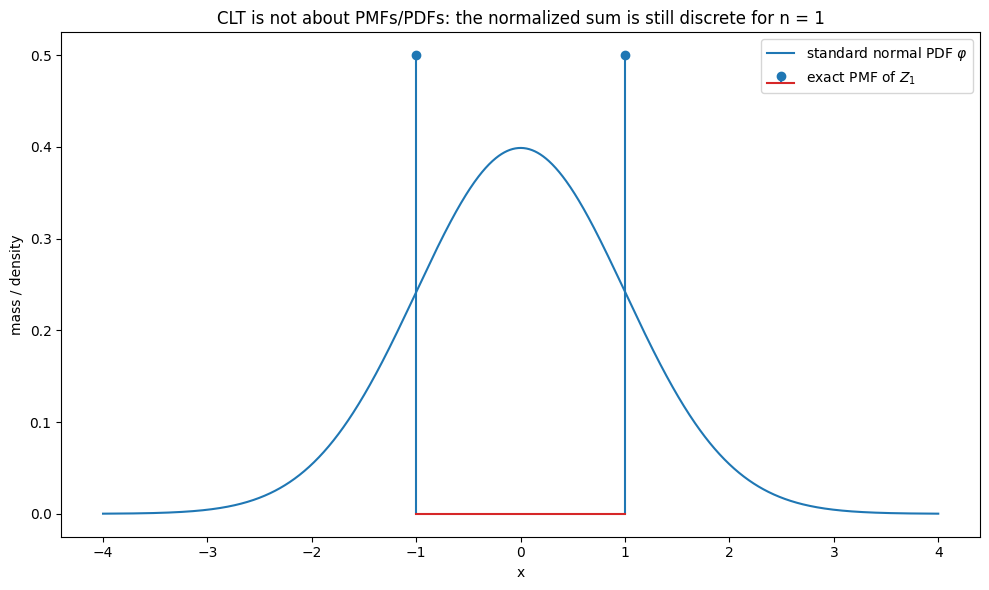

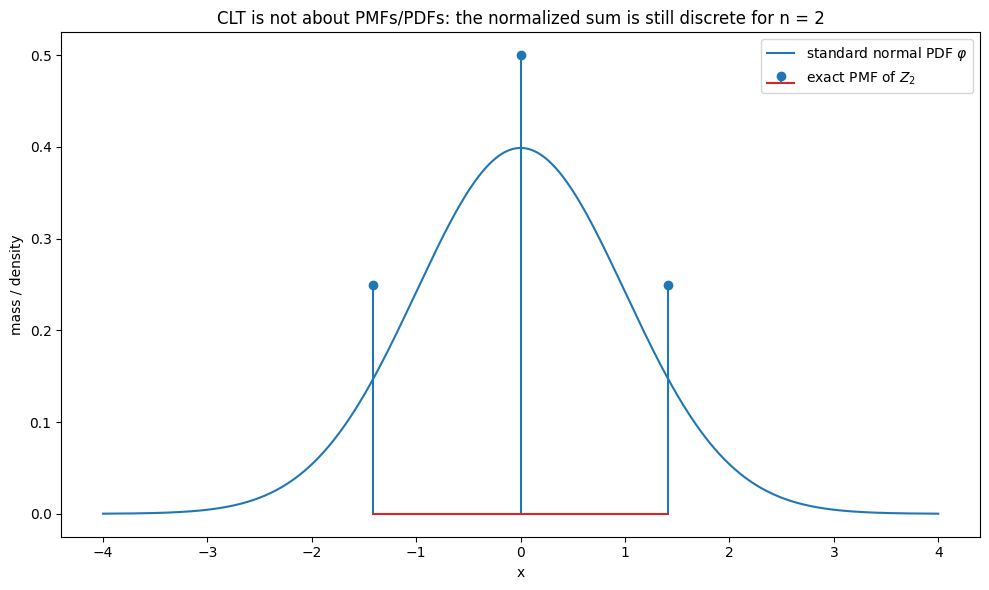

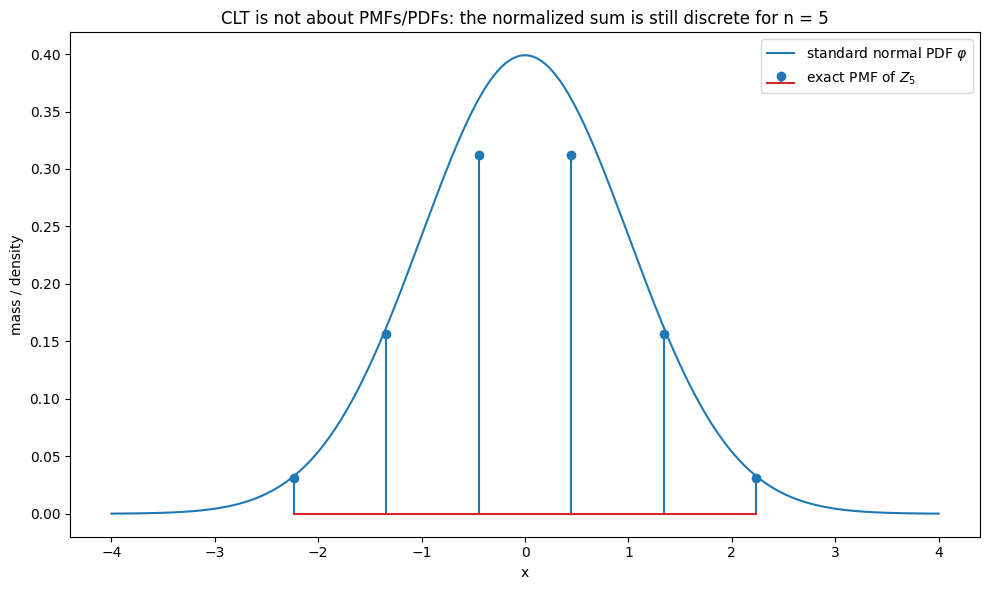

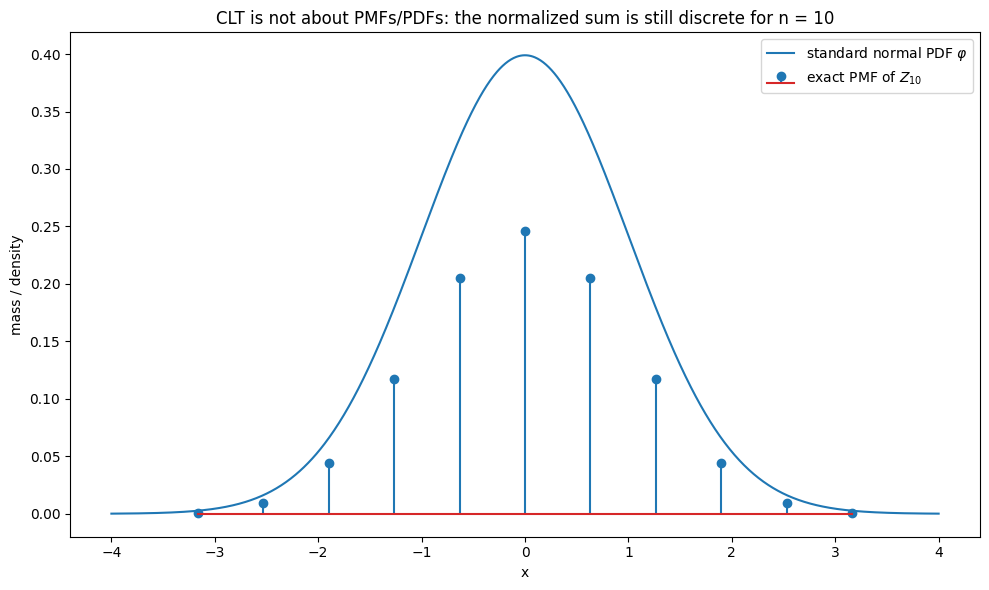

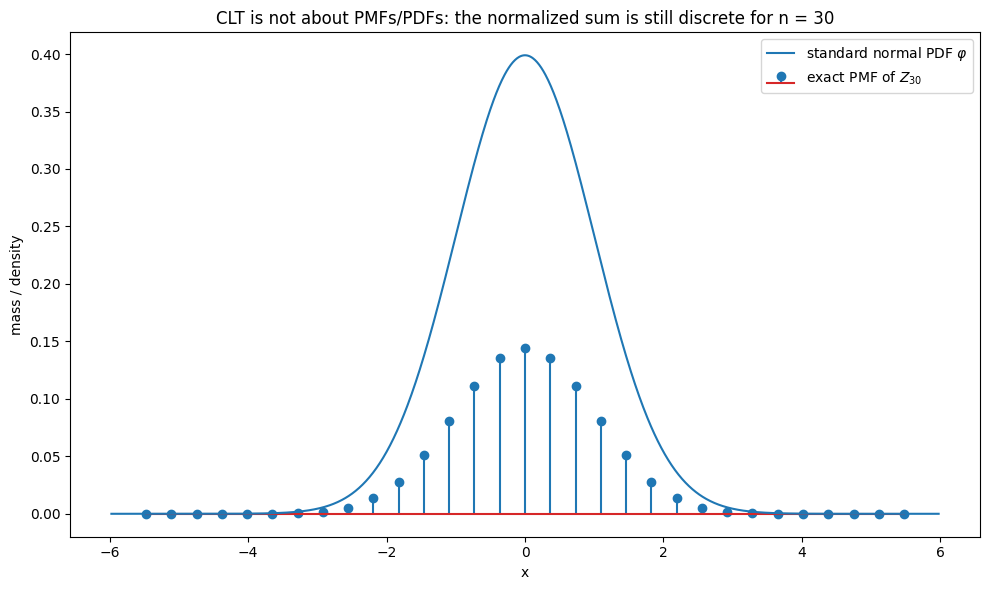

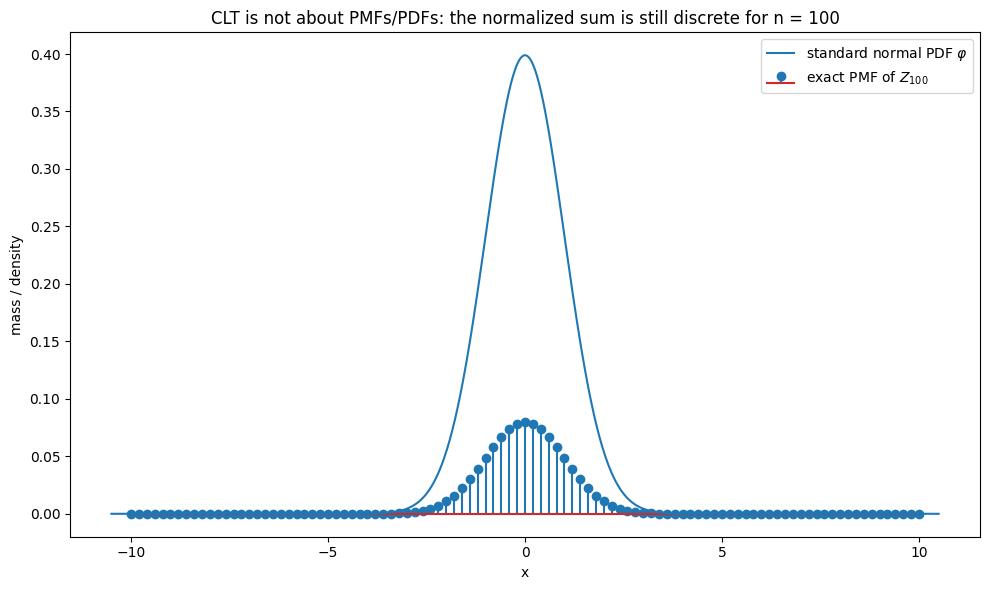

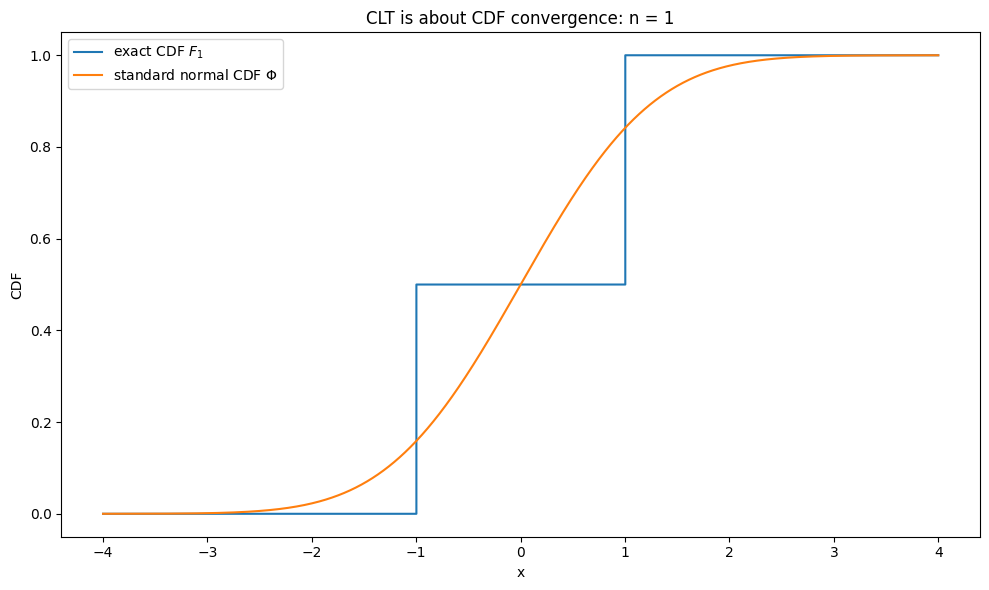

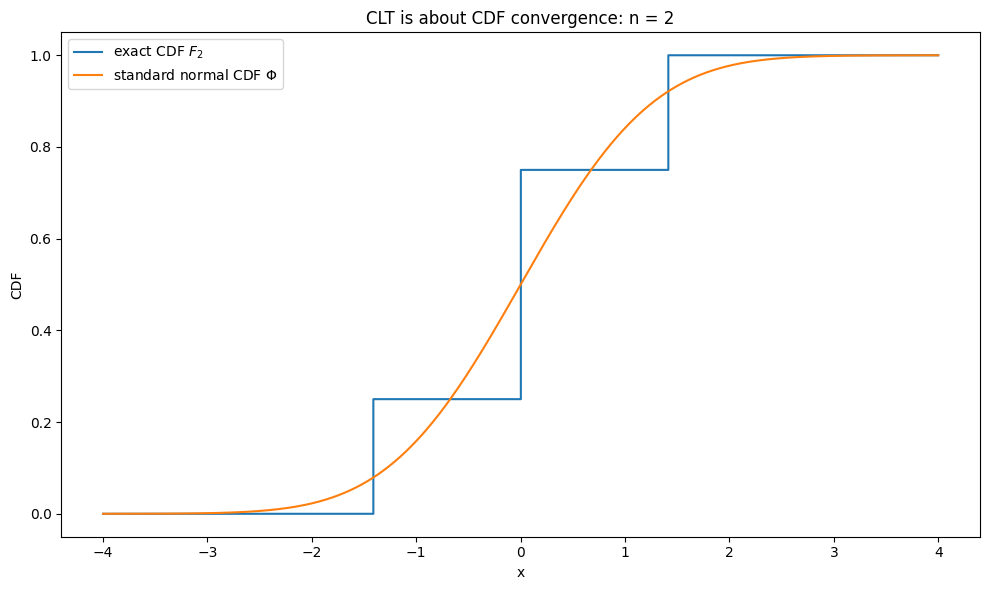

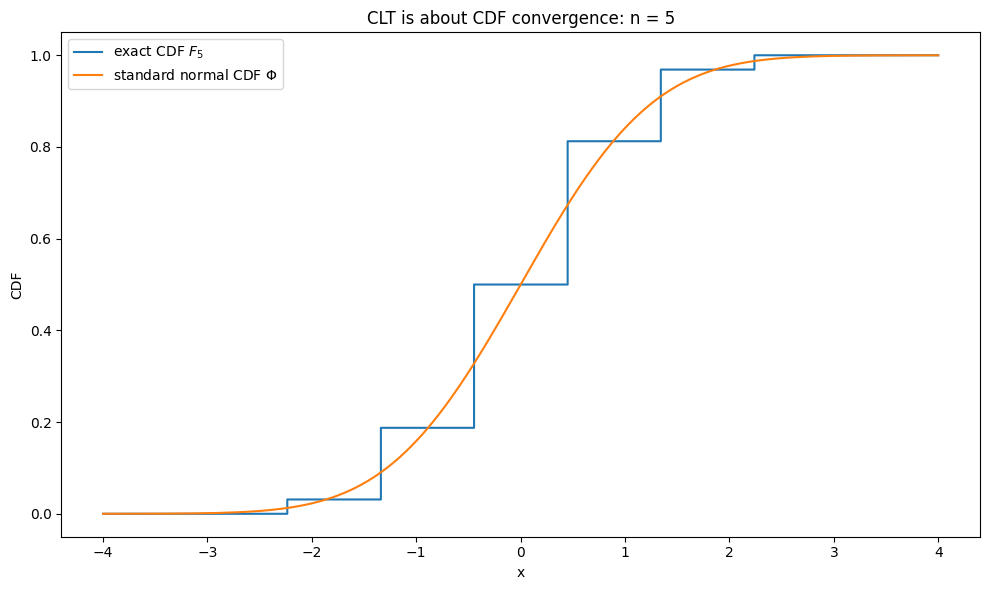

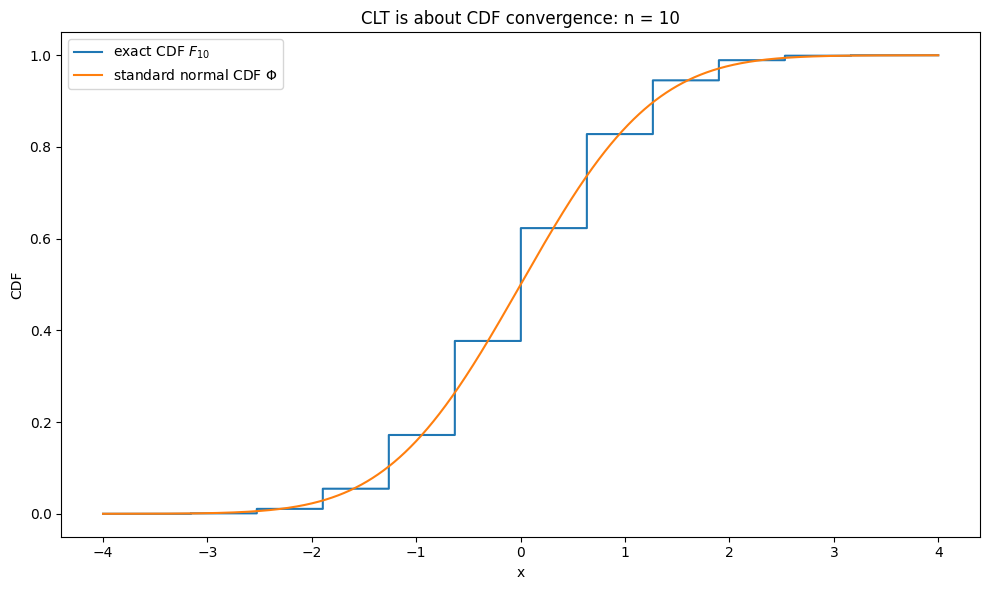

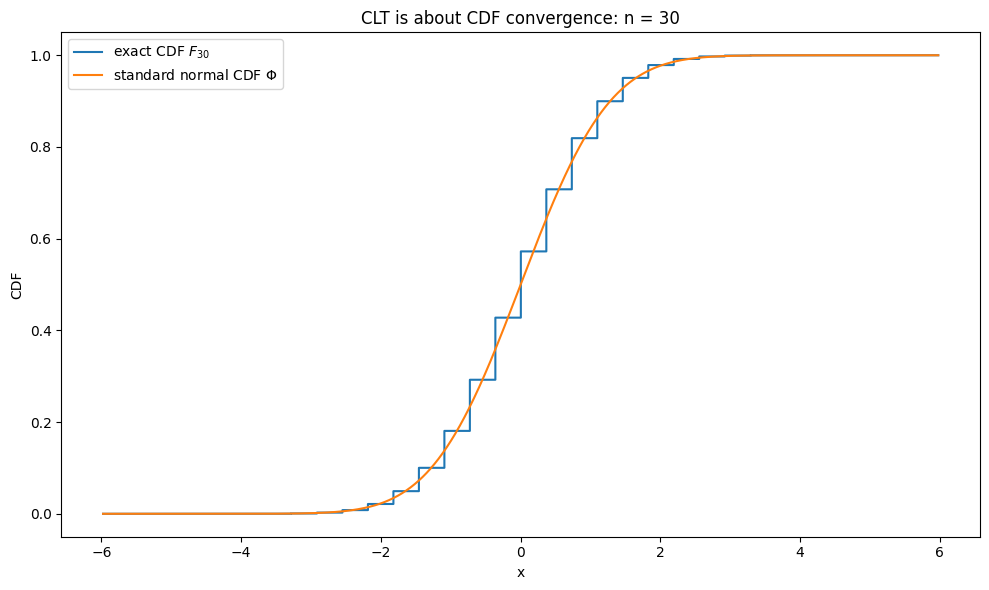

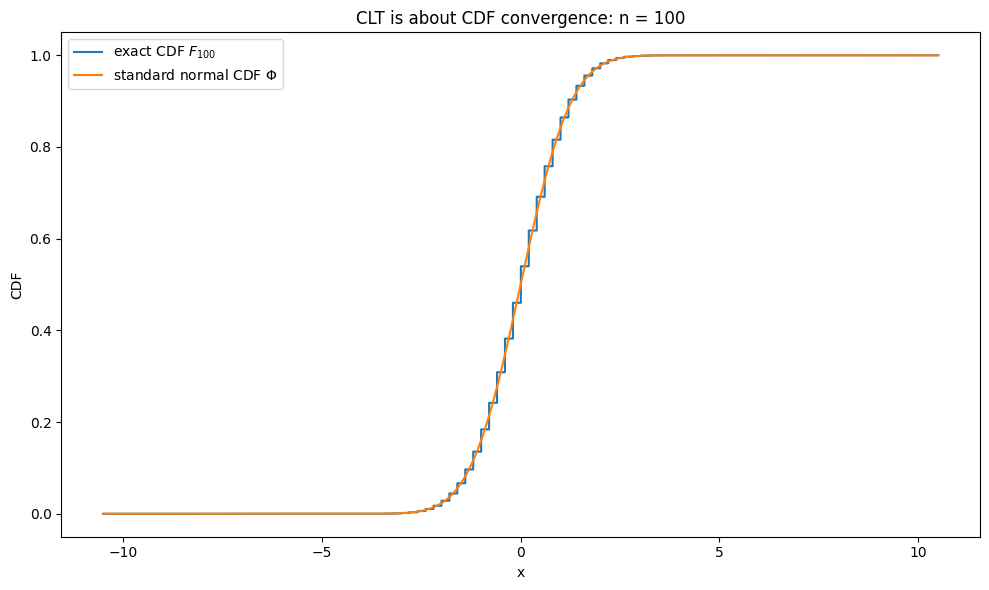

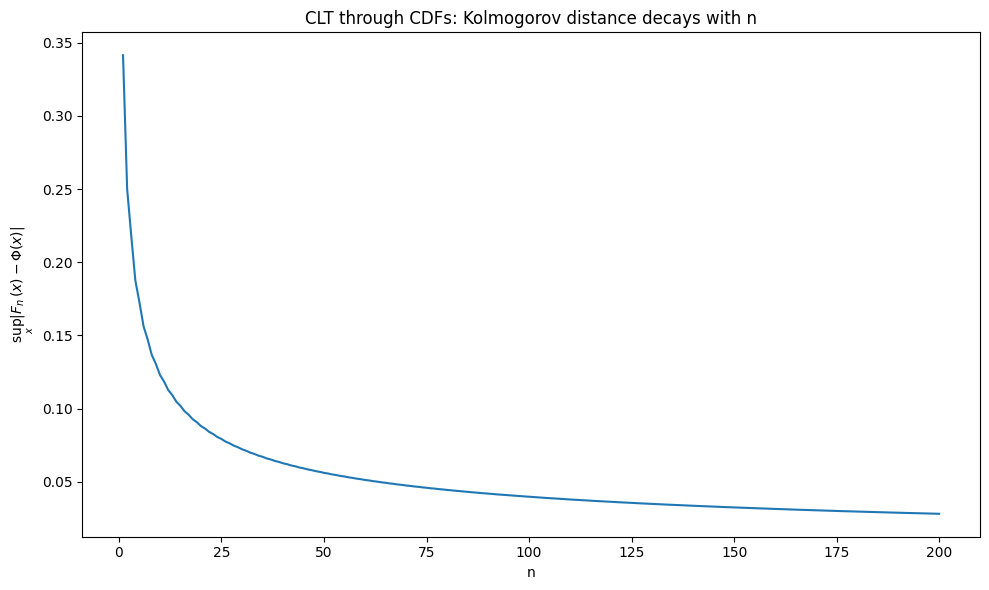

In [ ]:
def rademacher_pmf_standardized(n: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Exact PMF of Z_n = (X_1 + ... + X_n) / sqrt(n)
    where X_i are Rademacher: P(X_i = +1) = P(X_i = -1) = 1/2.

    Since S_n = 2K - n with K ~ Bin(n, 1/2), we get an exact lattice law.
    """
    k = np.arange(n + 1)
    s = 2 * k - n
    z = s / math.sqrt(n)
    pmf = np.array([math.comb(n, int(ki)) for ki in k], dtype=float) / (2**n)
    return z, pmf


def exact_discrete_cdf(x: np.ndarray, support: np.ndarray, pmf: np.ndarray) -> np.ndarray:
    out = np.zeros_like(x, dtype=float)
    for i, xi in enumerate(x):
        out[i] = pmf[support <= xi].sum()
    return out


def clt_demo(n_list: list[int] | None = None) -> None:
    """
    Uses the discrete Rademacher example to make the pedagogical point:

    - For every finite n, Z_n has a PMF on a lattice.
    - So there is no density f_n that could converge pointwise to φ.
    - Yet the CDF F_n does converge to Φ.

    Produces three figures:
    1) PMF spikes versus normal density
    2) Exact CDF versus normal CDF
    3) Kolmogorov distance versus n
    """
    if n_list is None:
        n_list = [1, 2, 5, 10, 30, 100]

    # Figure 1: PMF spikes with standard normal PDF overlay
    for n in n_list:
        z, pmf = rademacher_pmf_standardized(n)
        x = np.linspace(min(-4, z.min() - 0.5), max(4, z.max() + 0.5), 1200)

        plt.figure(figsize=(10, 6))
        plt.stem(z, pmf, label=fr"exact PMF of $Z_{{{n}}}$")
        plt.plot(x, normal_pdf(x), label=r"standard normal PDF $\varphi$")
        plt.xlabel("x")
        plt.ylabel("mass / density")
        plt.title(
            f"CLT is not about PMFs/PDFs: the normalized sum is still discrete for n = {n}"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Figure 2: exact CDF vs standard normal CDF
    for n in n_list:
        z, pmf = rademacher_pmf_standardized(n)
        x = np.linspace(min(-4, z.min() - 0.5), max(4, z.max() + 0.5), 2000)
        Fn = exact_discrete_cdf(x, z, pmf)
        Phi = normal_cdf(x)

        plt.figure(figsize=(10, 6))
        plt.step(x, Fn, where="post", label=fr"exact CDF $F_{{{n}}}$")
        plt.plot(x, Phi, label=r"standard normal CDF $\Phi$")
        plt.xlabel("x")
        plt.ylabel("CDF")
        plt.title(f"CLT is about CDF convergence: n = {n}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Figure 3: Kolmogorov distance over n
    n_grid = np.arange(1, 201)
    ks = np.empty_like(n_grid, dtype=float)

    for idx, n in enumerate(n_grid):
        z, pmf = rademacher_pmf_standardized(int(n))

        # To capture the sup norm between a step CDF and a continuous CDF,
        # evaluate both just to the left and just to the right of each jump.
        support = np.sort(z)
        mids = (support[:-1] + support[1:]) / 2
        probe = np.concatenate(
            [
                np.array([-6.0]),
                support - 1e-10,
                support,
                mids,
                np.array([6.0]),
            ]
        )
        probe.sort()

        Fn = exact_discrete_cdf(probe, z, pmf)
        Phi = normal_cdf(probe)
        ks[idx] = np.max(np.abs(Fn - Phi))

    plt.figure(figsize=(10, 6))
    plt.plot(n_grid, ks)
    plt.xlabel("n")
    plt.ylabel(r"$\sup_x |F_n(x) - \Phi(x)|$")
    plt.title("CLT through CDFs: Kolmogorov distance decays with n")
    plt.tight_layout()
    plt.show()

clt_demo()

# 4) CLT Histogram for Non-Gaussian Parent Laws

### Explanation

This demonstration reinforces the Central Limit Theorem by illustrating how the distribution of standardized sums approaches a normal distribution even when the underlying (parent) distribution of individual random variables is non-Gaussian. This is particularly useful for visual intuition, even though, as discussed in the main CLT section, the theorem is strictly about the convergence of cumulative distribution functions (CDFs) rather than probability density functions (PDFs) or probability mass functions (PMFs).

### Simulation Details

We consider two non-Gaussian parent distributions:

1.  **Exponential Distribution**: Let $X_i \sim \text{Exponential}(\lambda=1)$. For this distribution, the mean is $\mu = 1/\lambda = 1$ and the variance is $\sigma^2 = 1/\lambda^2 = 1$. Each $X_i$ is non-negative and highly skewed.

2.  **Bernoulli Distribution**: Let $X_i \sim \text{Bernoulli}(p=0.3)$. For this, the mean is $\mu = p = 0.3$ and the variance is $\sigma^2 = p(1-p) = 0.3 \times 0.7 = 0.21$. This is a discrete distribution.

For each parent distribution and for increasing values of $n$ (the number of random variables summed), we generate a large number of sample sums, standardize them, and plot their histograms.

The standardized sum $Z_n$ is calculated as:

$$ Z_n = \frac{\sum_{i=1}^n X_i - n\mu}{\sigma\sqrt{n}} $$

where $\mu$ and $\sigma$ are the mean and standard deviation of the parent distribution, respectively.

We overlay the histogram of $Z_n$ with the PDF of the standard normal distribution $\varphi(x)$. As $n$ increases, the histogram of the standardized sums is expected to visually resemble the bell curve of the standard normal distribution, providing a strong visual confirmation of the CLT's implications for the shape of the sum's distribution.

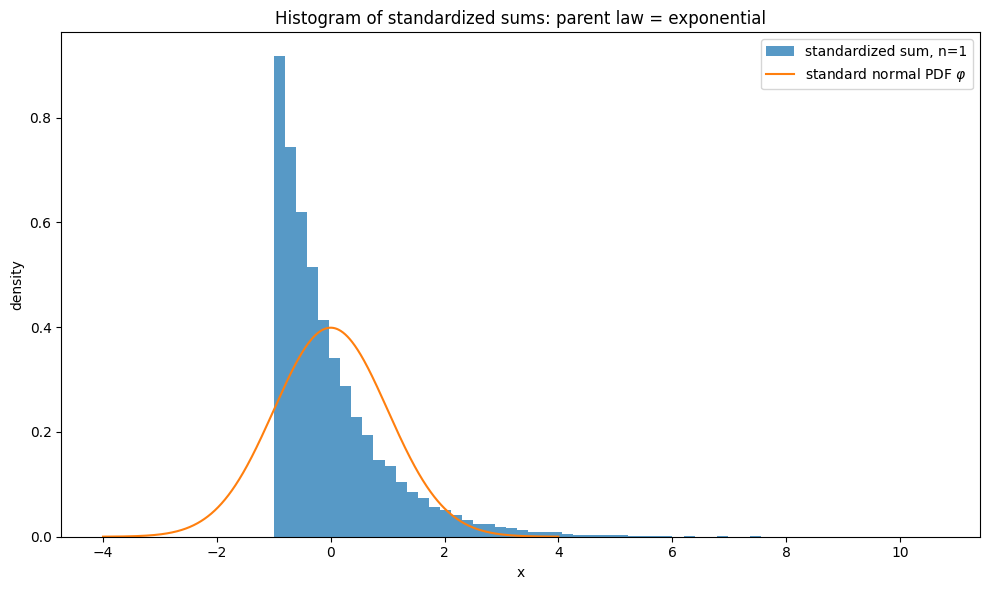

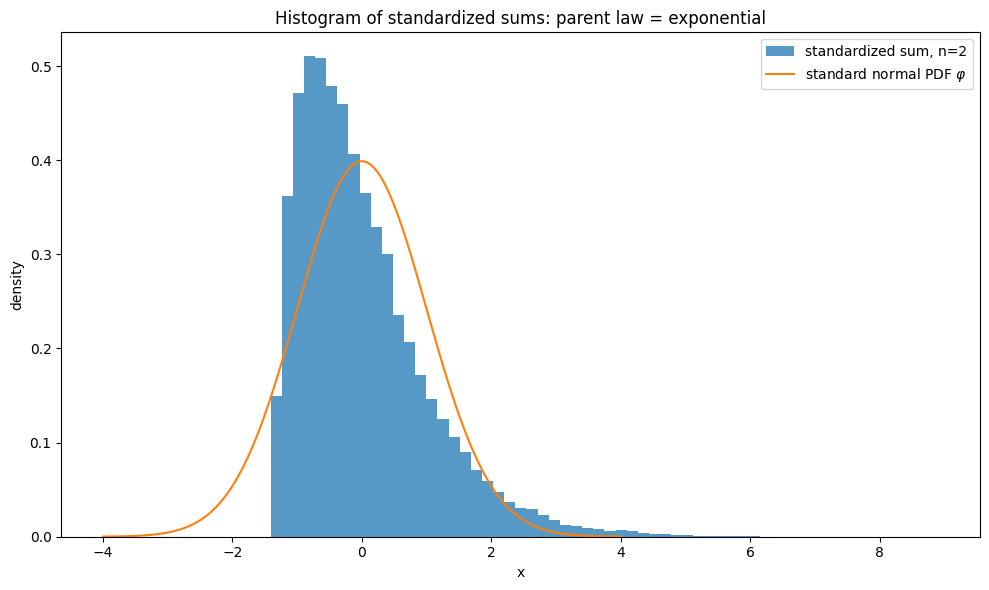

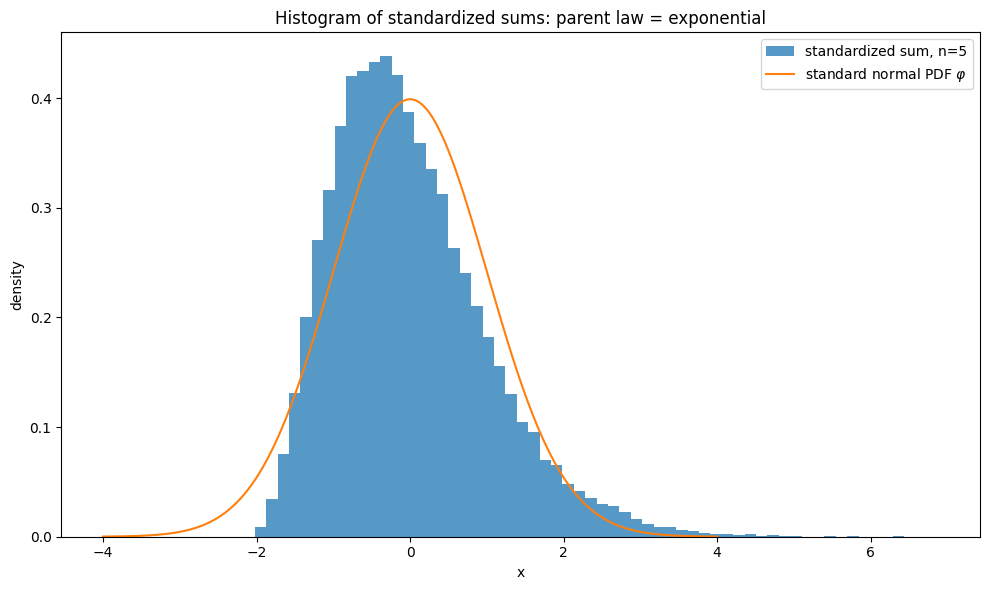

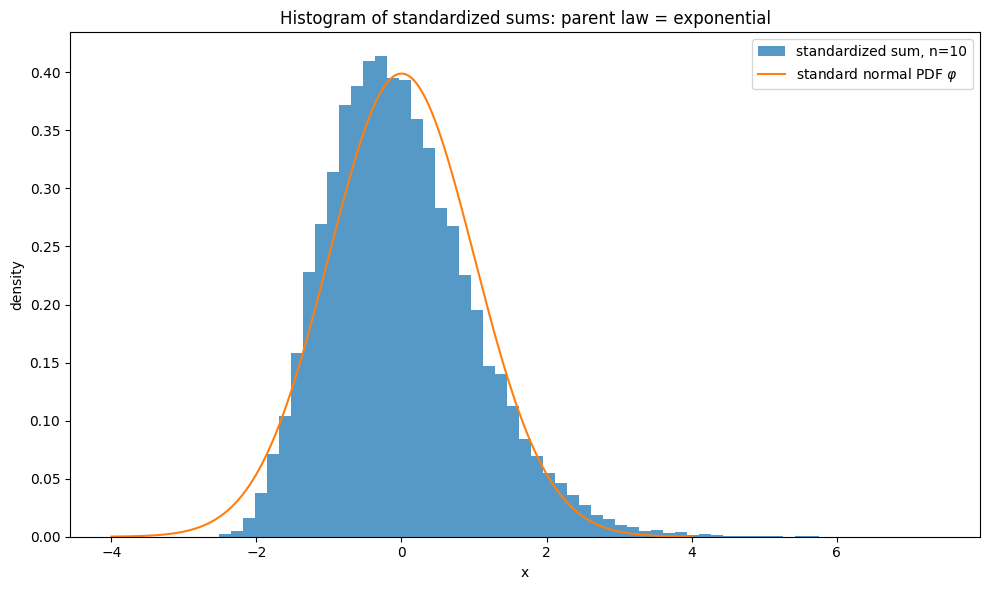

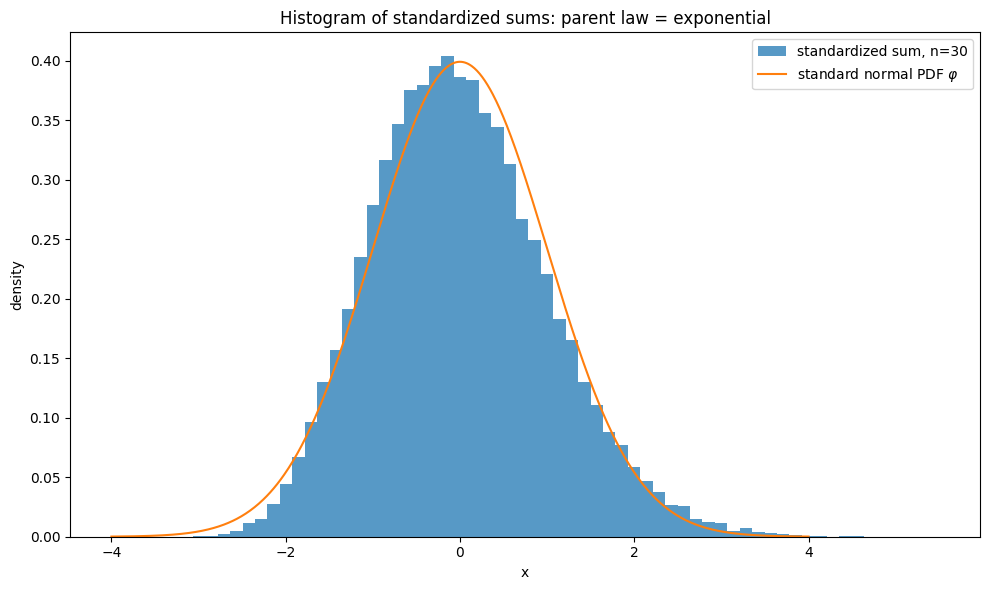

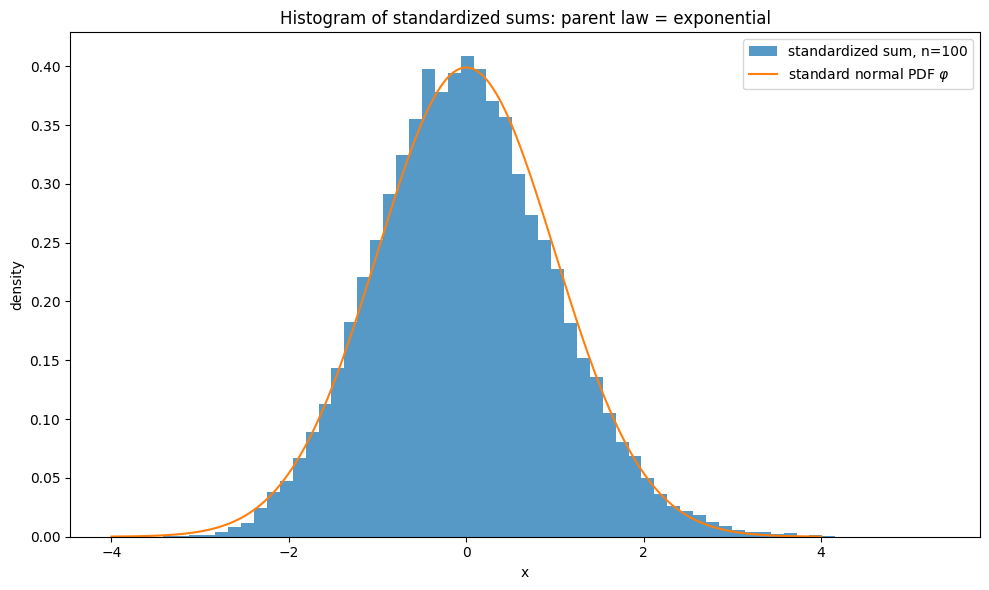

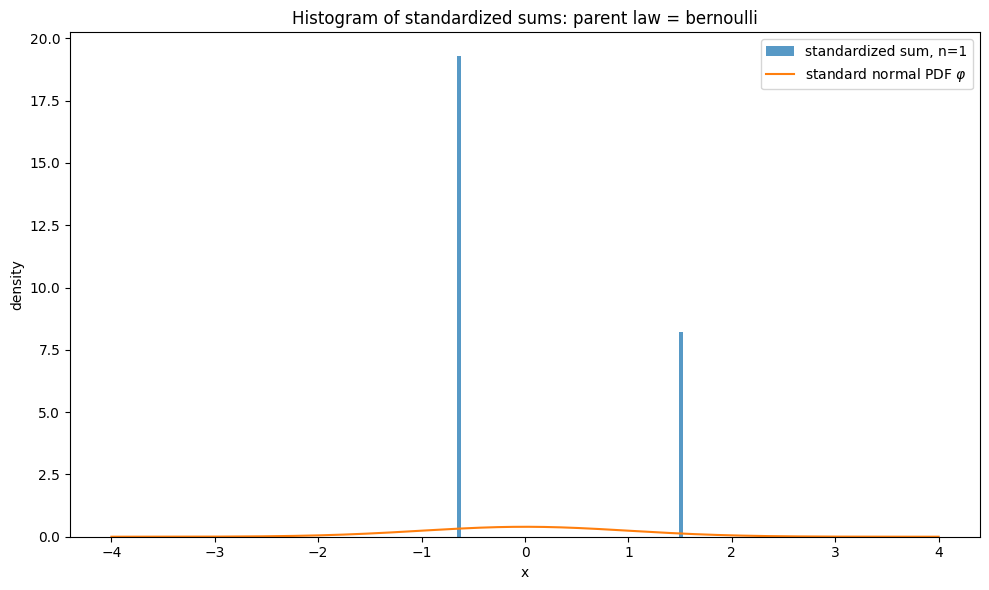

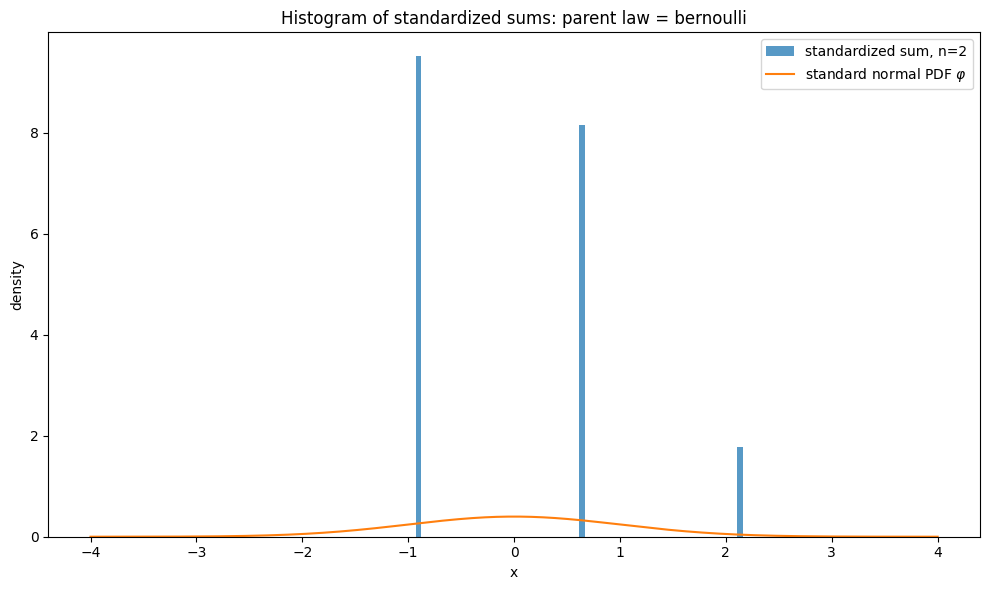

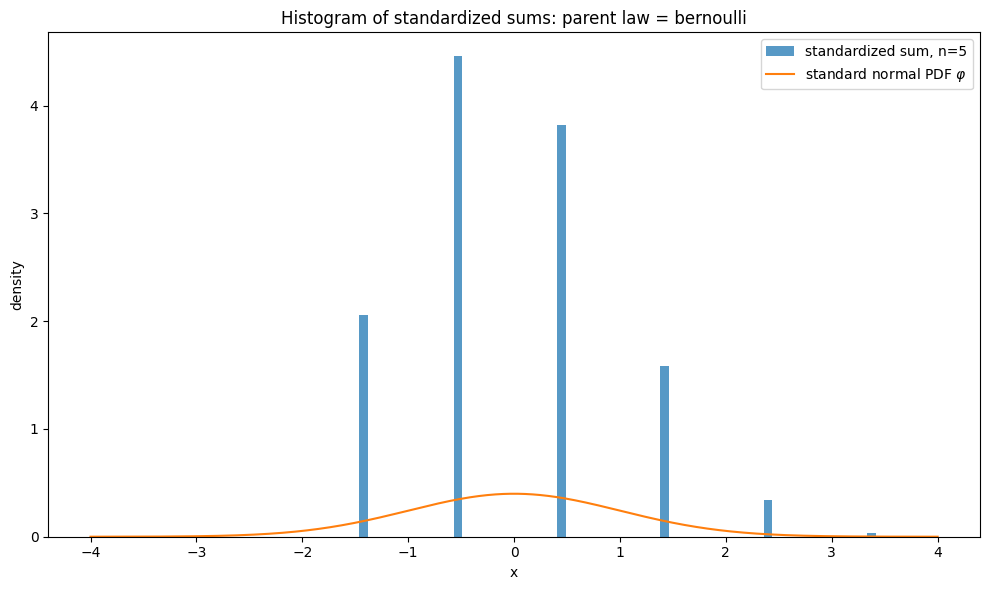

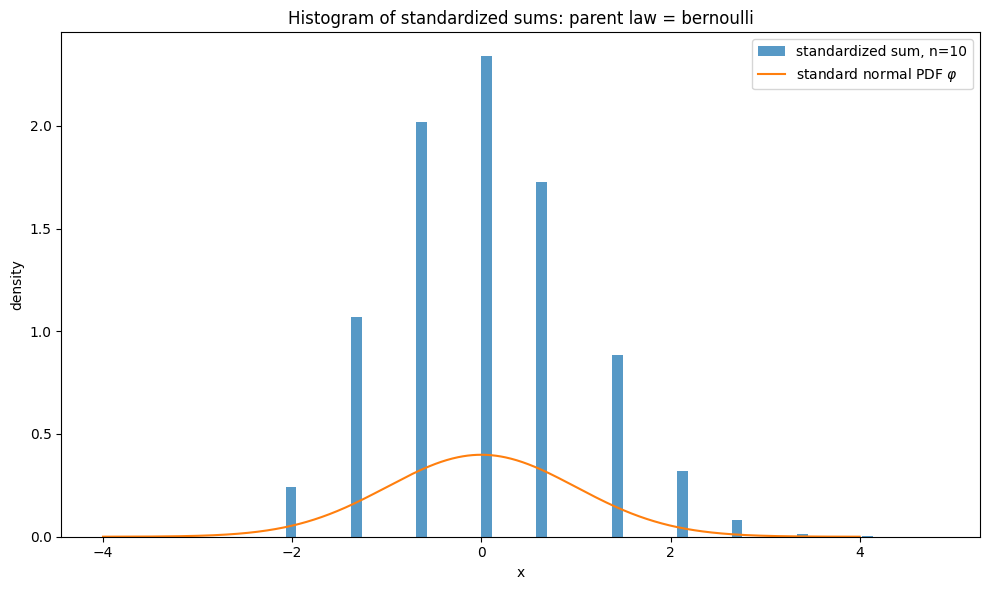

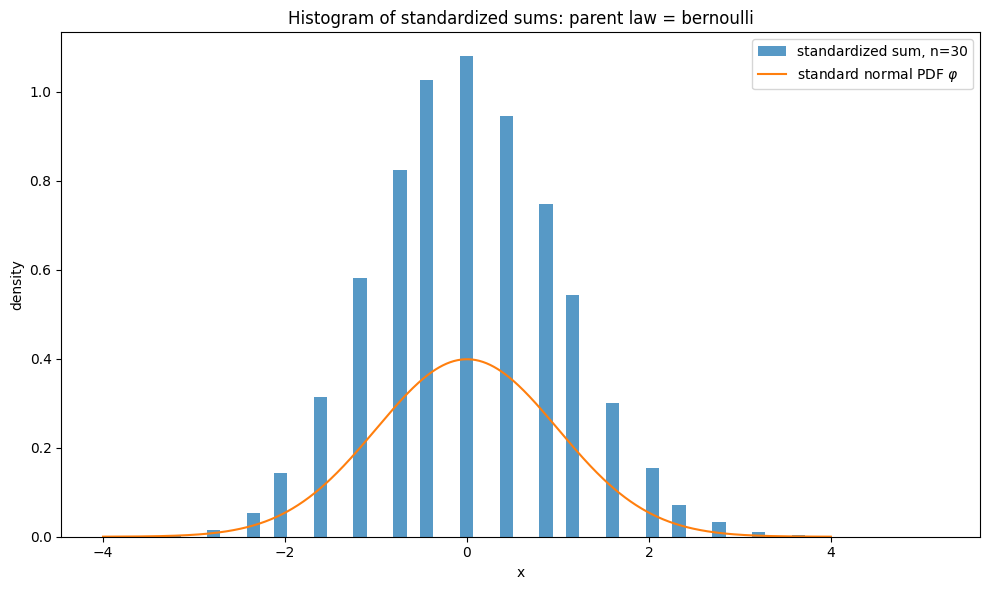

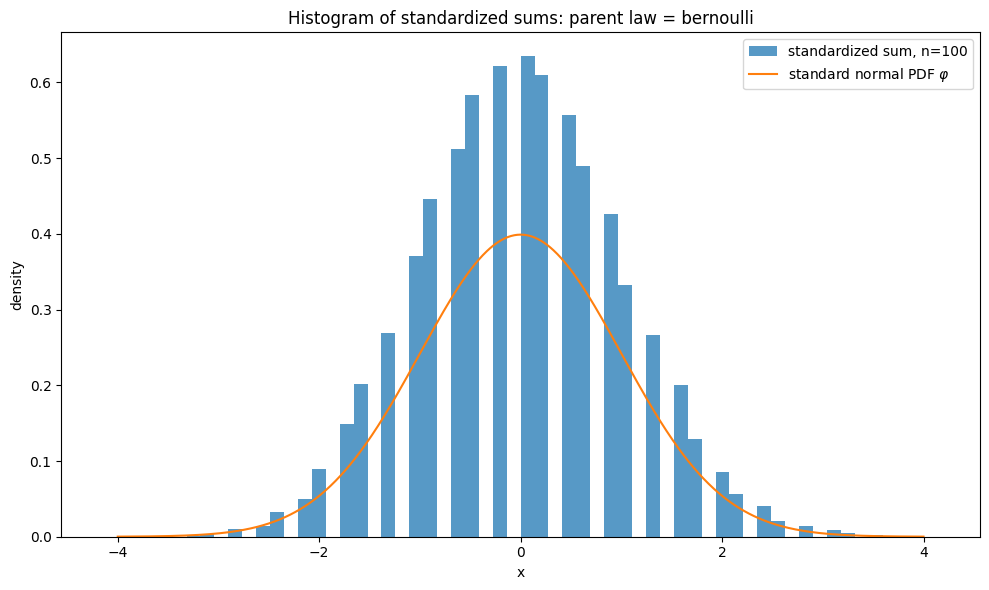

In [ ]:
def clt_histogram_demo(
    dist: str = "exponential",
    n_list: list[int] | None = None,
    samples: int = 40000,
    seed: int = 19,
) -> None:
    """
    Optional extra: standardized sums for a non-Gaussian parent law.

    Useful after the discrete CLT demo:
    - the histogram starts to resemble a bell curve,
    - but the theorem is still about distribution functions.
    """
    if n_list is None:
        n_list = [1, 2, 5, 10, 30, 100]

    rng = np.random.default_rng(seed)

    if dist == "exponential":
        mu, sigma = 1.0, 1.0
        sampler = lambda size: rng.exponential(scale=1.0, size=size)
    elif dist == "bernoulli":
        p = 0.3
        mu, sigma = p, math.sqrt(p * (1 - p))
        sampler = lambda size: rng.binomial(1, p, size=size)
    else:
        raise ValueError("dist must be 'exponential' or 'bernoulli'")

    for n in n_list:
        x = sampler((samples, n))
        z = (x.sum(axis=1) - n * mu) / (sigma * math.sqrt(n))

        grid = np.linspace(-4, 4, 800)

        plt.figure(figsize=(10, 6))
        plt.hist(z, bins=60, density=True, alpha=0.75, label=f"standardized sum, n={n}")
        plt.plot(grid, normal_pdf(grid), label=r"standard normal PDF $\varphi$")
        plt.xlabel("x")
        plt.ylabel("density")
        plt.title(f"Histogram of standardized sums: parent law = {dist}")
        plt.legend()
        plt.tight_layout()
        plt.show()


clt_histogram_demo(dist="exponential")
clt_histogram_demo(dist="bernoulli")